---

# Label distrubution and analysis
> Oliver Jung

---

### Imports

In [84]:
import json
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

### Datenpfade

Gegebenenfalls anpassen!

In [85]:
BASE_DIR = Path("/home/oli/Datasets/NERC/finalData")

datasets = {
    "ds_fine_ds": BASE_DIR / "ds_fine_ds",
    "ds_fine_crowd": BASE_DIR / "ds_fine_crowd",
    "ds_figer": BASE_DIR / "ds_figer",
    "ds_onto": BASE_DIR / "ds_onto",
}

### Pfad für die Plots

In [86]:
from pathlib import Path

PLOT_DIR = Path("/home/oli/Schreibtisch/Semantik_Projekt/Plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Plots werden gespeichert in:", PLOT_DIR)

Plots werden gespeichert in: /home/oli/Schreibtisch/Semantik_Projekt/Plots


### Load Data

In [87]:
def load_split_stream(path):
    if not path.exists():
        return
    
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                yield json.loads(line)


def load_dataset(dataset_path):
    return {
        "train": load_split_stream(dataset_path / "train.json"),
        "validation": load_split_stream(dataset_path / "validation.json"),
        "test": load_split_stream(dataset_path / "test.json"),
    }

all_data = {name: load_dataset(path) for name, path in datasets.items()}

print("Datasets geladen:", list(all_data.keys()))

Datasets geladen: ['ds_fine_ds', 'ds_fine_crowd', 'ds_figer', 'ds_onto']


### OntoNotes Mapping

Da OntoNotes im Dataset nicht ersichtlich ist um welches Label es sich handelt, mappen wir diese.

In [88]:
id2label = {
    0: "O",
    1: "B-PER",
    2: "I-PER",
    3: "B-ORG",
    4: "I-ORG",
    5: "B-LOC",
    6: "I-LOC",
    7: "B-MISC",
    8: "I-MISC",
}

### Extrahiere OntoNotes Entitäten

In [89]:
def extract_ontonotes_entities(sample):
    ner_tags = sample.get("ner_tags", [])
    
    entities = []
    current_entity = None

    for tag in ner_tags:
        label = id2label.get(tag, "O")

        if label == "O":
            if current_entity:
                entities.append(current_entity)
                current_entity = None
            continue

        prefix, ent_type = label.split("-")

        if prefix == "B":
            if current_entity:
                entities.append(current_entity)
            current_entity = ent_type

        elif prefix == "I":
            continue

    if current_entity:
        entities.append(current_entity)

    return entities

### Label extrahieren:

In [90]:
def extract_labels(sample, dataset_name):

    if dataset_name == "ds_figer":
        return sample.get("labels", [])

    elif dataset_name in ["ds_fine_ds", "ds_fine_crowd"]:
        return sample.get("y_str", [])

    elif dataset_name == "ds_onto":
        return extract_ontonotes_entities(sample)

    return []

### Labels normieren (FIGER)

In [91]:
def normalize_label(label):
    return label.strip().lower()

In [95]:
def get_top_level(label):
    return label.split("/")[1] if "/" in label else label

### Analyse

In [ ]:
def analyze_dataset_stream(dataset_path, dataset_name):
    
    label_counter = Counter()
    multi_word_count = 0
    labels_per_entity = []
    total_entities = 0

    for split in ["train", "validation", "test"]:
        file_path = dataset_path / f"{split}.json"
        
        if not file_path.exists():
            continue

        for sample in load_split_stream(file_path):

            # OntoNotes Spezialfall
            if dataset_name == "ds_onto":
                ner_tags = sample.get("ner_tags", [])
                tokens = sample.get("tokens", [])

                current_entity_tokens = []
                current_label = None

                for i, tag in enumerate(ner_tags):
                    label = id2label.get(tag, "O")

                    if label == "O":
                        if current_entity_tokens:
                            total_entities += 1
                            labels_per_entity.append(1)
                            label_counter.update([current_label])

                            if len(current_entity_tokens) > 1:
                                multi_word_count += 1

                            current_entity_tokens = []
                            current_label = None
                        continue

                    prefix, ent_type = label.split("-")

                    if prefix == "B":
                        if current_entity_tokens:
                            total_entities += 1
                            labels_per_entity.append(1)
                            label_counter.update([current_label])

                            if len(current_entity_tokens) > 1:
                                multi_word_count += 1

                        current_entity_tokens = [tokens[i]]
                        current_label = ent_type

                    elif prefix == "I":
                        current_entity_tokens.append(tokens[i])

                # letzte Entity
                if current_entity_tokens:
                    total_entities += 1
                    labels_per_entity.append(1)
                    label_counter.update([current_label])

                    if len(current_entity_tokens) > 1:
                        multi_word_count += 1

            # andere Datensätze
            else:
                total_entities += 1
 
                labels = extract_labels(sample, dataset_name)
                labels = [normalize_label(l) for l in labels]
                labels = [get_top_level(l) for l in labels]
                labels = list(set(labels))  # Duplikate entfernen (FIGER)

                if "tokens" in sample:
                    tokens = sample["tokens"]
                elif "mention_span" in sample:
                    tokens = sample["mention_span"].split()
                else:
                    tokens = []

                label_counter.update(labels)
                labels_per_entity.append(len(labels))

                if len(tokens) > 1:
                    multi_word_count += 1

    return {
        "total_entities": total_entities,
        "unique_labels": len(label_counter),
        "label_distribution": label_counter,
        "multi_word_entities": multi_word_count,
        "multi_word_ratio": multi_word_count / total_entities if total_entities else 0,
        "avg_labels_per_entity": np.mean(labels_per_entity) if labels_per_entity else 0,
        "max_labels_per_entity": max(labels_per_entity) if labels_per_entity else 0,
        "labels_per_entity_list": labels_per_entity,
    }

In [97]:
def get_top_labels(counter, top_n=20):
    return dict(counter.most_common(top_n))

### run Analysis

In [98]:
results = {
    name: analyze_dataset_stream(path, name)
    for name, path in datasets.items()
}

for name, stats in results.items():
    print(f"\n===== {name} =====")
    print(f"Entities: {stats['total_entities']}")
    print(f"Unique Labels: {stats['unique_labels']}")
    print(f"Multi-word Entities: {stats['multi_word_entities']} ({stats['multi_word_ratio']:.2%})")
    print(f"Avg Labels/Entity: {stats['avg_labels_per_entity']:.2f}")
    print(f"Max Labels/Entity: {stats['max_labels_per_entity']}")


===== ds_fine_ds =====
Entities: 3152711
Unique Labels: 4261
Multi-word Entities: 1749718 (55.50%)
Avg Labels/Entity: 2.18
Max Labels/Entity: 11

===== ds_fine_crowd =====
Entities: 5994
Unique Labels: 2519
Multi-word Entities: 3000 (50.05%)
Avg Labels/Entity: 5.39
Max Labels/Entity: 19

===== ds_figer =====
Entities: 4047079
Unique Labels: 91
Multi-word Entities: 4047079 (100.00%)
Avg Labels/Entity: 4.62
Max Labels/Entity: 25

===== ds_onto =====
Entities: 35089
Unique Labels: 4
Multi-word Entities: 12917 (36.81%)
Avg Labels/Entity: 1.00
Max Labels/Entity: 1


### Analyse von Label Properties

In [99]:
def analyze_label_properties(dataset_path, dataset_name):

    total = 0
    no_label_count = 0
    labels_per_entity = []

    for split in ["train", "validation", "test"]:
        file_path = dataset_path / f"{split}.json"
        
        if not file_path.exists():
            continue

        for sample in load_split_stream(file_path):
            total += 1

            labels = extract_labels(sample, dataset_name)

            if len(labels) == 0:
                no_label_count += 1

            labels_per_entity.append(len(labels))

    return {
        "no_label_ratio": no_label_count / total if total else 0,
        "labels_per_entity": labels_per_entity
    }


label_analysis = {
    name: analyze_label_properties(path, name)
    for name, path in datasets.items()
}

### Extremfälle FIGER

In [ ]:
# Funktioniert noch nicht so richtig...

extreme_cases = []

for split in ["train", "validation", "test"]:
    file_path = figer_path / f"{split}.json"
    
    if not file_path.exists():
        continue

    for sample in load_split_stream(file_path):
        labels = sample.get("labels", [])

        if len(labels) > 50:
            extreme_cases.append(sample)

print(f"Gefundene extreme Fälle: {len(extreme_cases)}")

Gefundene extreme Fälle: 126630


# Plot Functions

### Dataset size comparison

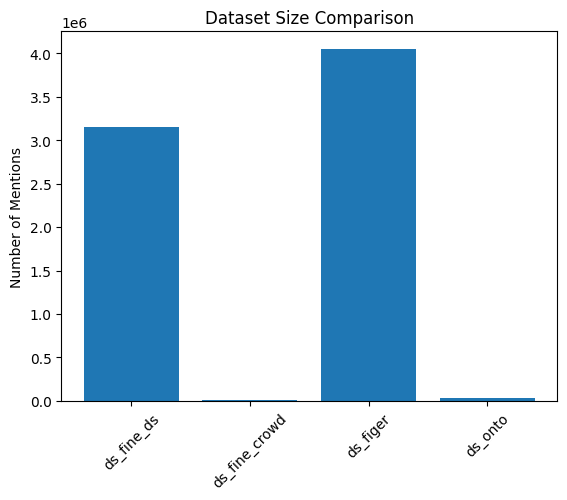

In [77]:
# Dataset size comparison
names = []
sizes = []

for name, stats in results.items():
    names.append(name)
    sizes.append(stats["total_entities"])

plt.figure()
plt.bar(names, sizes)
plt.title("Dataset Size Comparison")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45)
plt.savefig(PLOT_DIR / "dataset_size.png", bbox_inches="tight")
plt.show()


### Average Labels per Mention

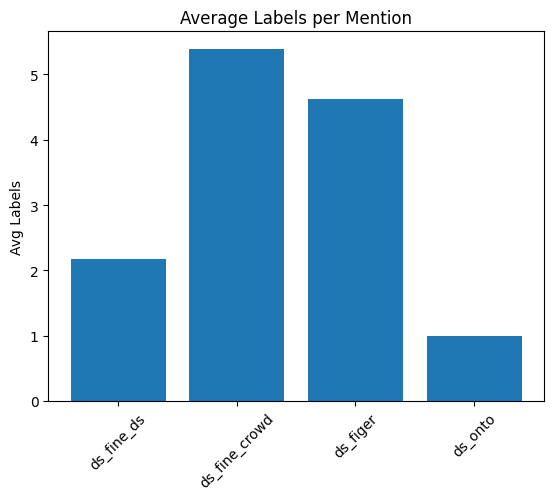

In [100]:
names = []
avg_labels = []

for name, stats in results.items():
    names.append(name)
    avg_labels.append(stats["avg_labels_per_entity"])

plt.figure()
plt.bar(names, avg_labels)
plt.title("Average Labels per Mention")
plt.ylabel("Avg Labels")
plt.xticks(rotation=45)
plt.savefig(PLOT_DIR / "avg_labels.png", bbox_inches="tight")
plt.show()

### Multi Word Vergleich

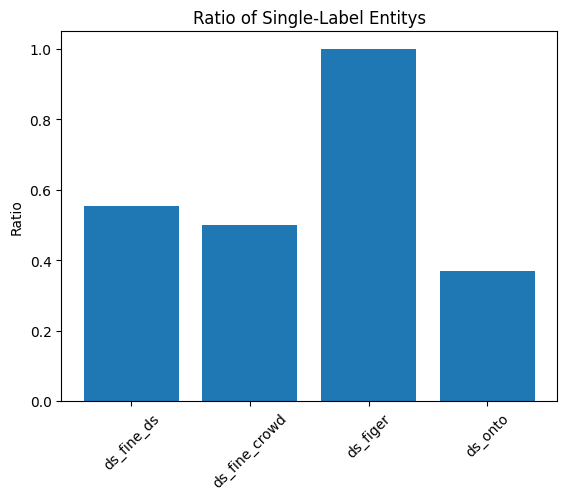

In [ ]:
names = []
ratios = []

for name, stats in results.items():
    names.append(name)
    ratios.append(stats["multi_word_ratio"])

plt.figure()
plt.bar(names, ratios)
plt.title("Ratio of single-Word Entitys")
plt.ylabel("Ratio")
plt.xticks(rotation=45)
plt.savefig(PLOT_DIR / "multi_word_ratio.png", bbox_inches="tight")
plt.show()

### Top Label per Dataset


Plotting Top Labels for ds_fine_ds


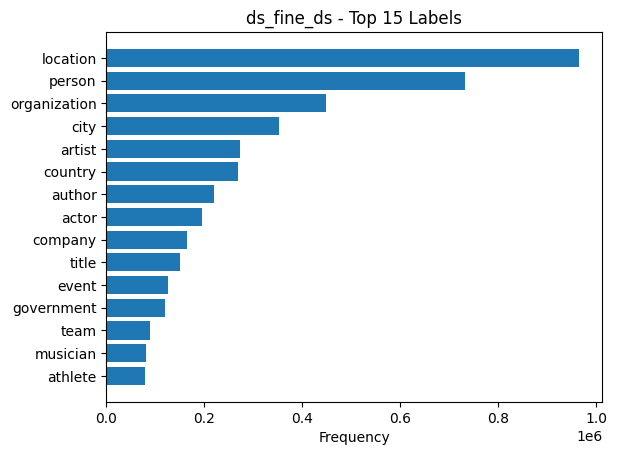


Plotting Top Labels for ds_fine_crowd


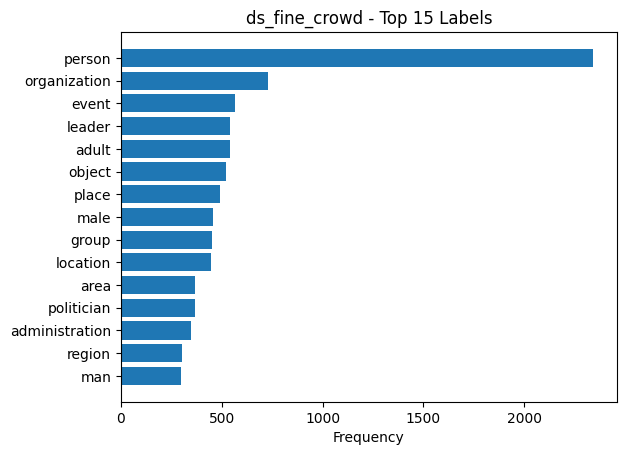


Plotting Top Labels for ds_figer


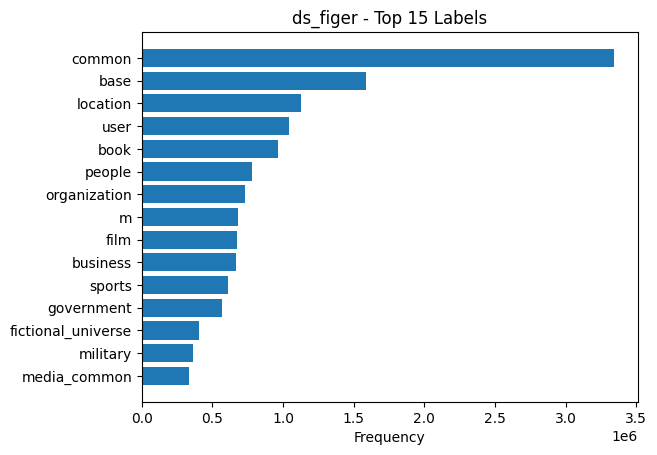


Plotting Top Labels for ds_onto


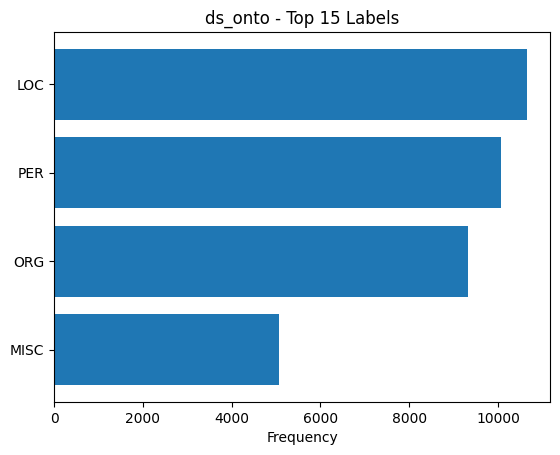

In [102]:
for name, stats in results.items():
    print(f"\nPlotting Top Labels for {name}")

    top_labels = get_top_labels(stats["label_distribution"], top_n=15)

    labels = list(top_labels.keys())
    counts = list(top_labels.values())

    plt.figure()
    plt.barh(labels, counts)
    plt.title(f"{name} - Top 15 Labels")
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.savefig(PLOT_DIR / f"{name}_top_labels.png", bbox_inches="tight")
    plt.show()

### Percentage of no Labels

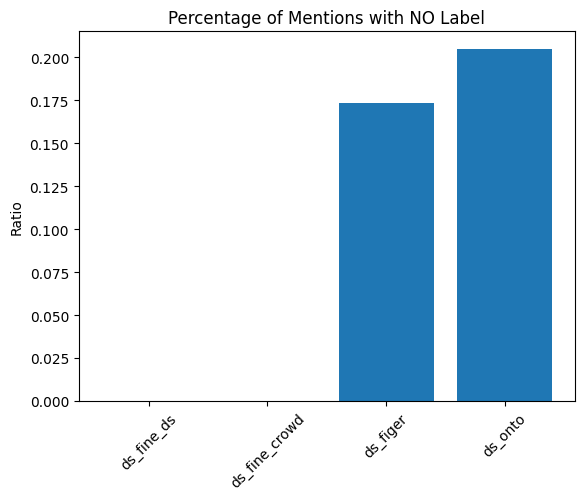

In [103]:
names = []
ratios = []

for name, stats in label_analysis.items():
    names.append(name)
    ratios.append(stats["no_label_ratio"])

plt.figure()
plt.bar(names, ratios)
plt.title("Percentage of Mentions with NO Label")
plt.ylabel("Ratio")
plt.xticks(rotation=45)
plt.savefig(PLOT_DIR / "no_label_ratio.png", bbox_inches="tight")
plt.show()

### Verteilung Labels pro Entität

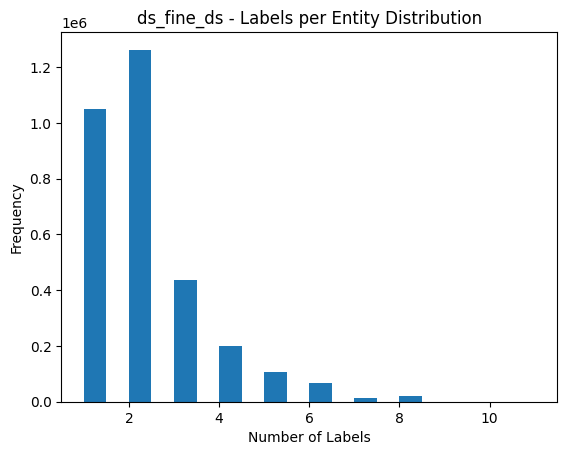

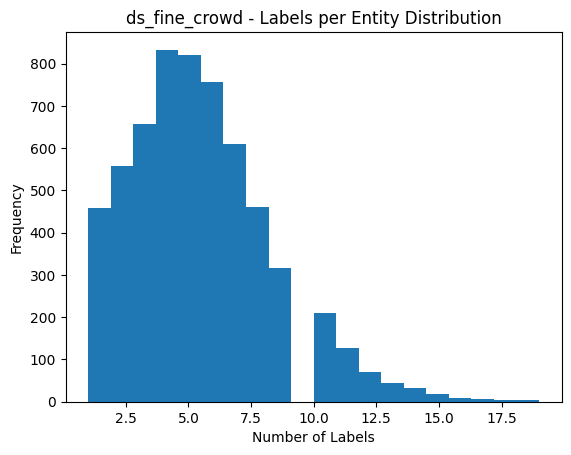

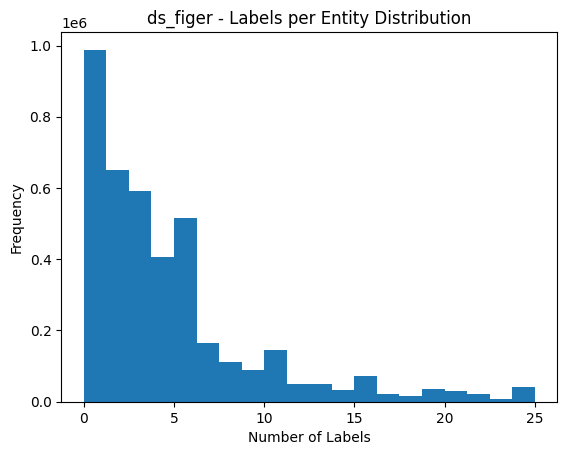

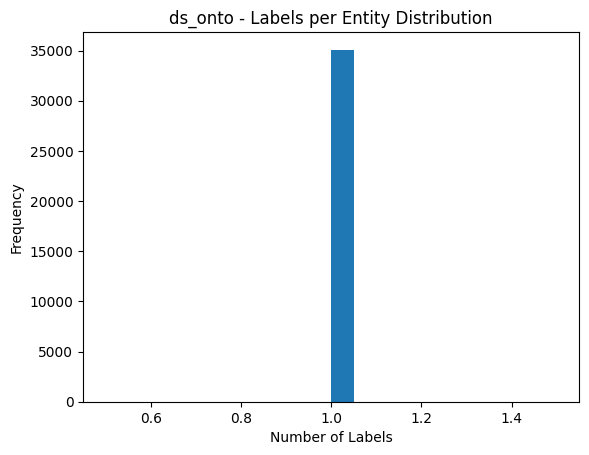

In [104]:
for name, stats in results.items():
    plt.figure()
    
    values = stats["labels_per_entity_list"]

    plt.hist(values, bins=20)
    plt.title(f"{name} - Labels per Entity Distribution")
    plt.xlabel("Number of Labels")
    plt.ylabel("Frequency")
    plt.savefig(PLOT_DIR / f"{name}_labels_per_entity.png", bbox_inches="tight")
    plt.show()